# Анализ эмоций по текстовому отрывку — Расширенная версия
### Дисциплина: Системы искусственного интеллекта и большие данные
### Практическое задание №4 (Extended)
**Преподаватель:** Медведев Константин Эдуардович

---

## Описание проекта
Проект посвящён задаче классификации эмоций по текстовым фрагментам.  
Используются следующие подходы:
1. **SimpleRNN** — базовая рекуррентная нейросеть (baseline)
2. **BiLSTM** — двунаправленная LSTM с механизмом внимания
3. **DistilBERT** — трансформер на основе механизма внимания (SOTA)

Дополнительно проводятся:
- **Сравнение SimpleRNN vs BiLSTM** — архитектурное сравнение
- **Эксперимент 1 (BiLSTM):** зависимость качества от размерности эмбеддингов и hidden_dim
- **Эксперимент 2 (BiLSTM):** зависимость качества от dropout
- **Эксперимент 3 (DistilBERT):** зависимость качества от learning rate
- **Эксперимент 4 (DistilBERT):** зависимость качества от количества размороженных слоёв

Все артефакты (графики, веса моделей) сохраняются в папку `artifacts/`.

**Классы эмоций:** sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5)

## 1. Установка зависимостей

In [6]:
!pip install kagglehub transformers torch scikit-learn pandas numpy matplotlib seaborn tqdm -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Сбор данных

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- Создаём папку для артефактов ----
ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print(f"Папка артефактов: {os.path.abspath(ARTIFACTS_DIR)}")

def save_fig(name):
    """Сохраняет текущий matplotlib-график в папку artifacts"""
    path = os.path.join(ARTIFACTS_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"  [saved] {path}")
    return path

Папка артефактов: c:\Users\User\git-package\aie-course\homeworks\GroupHW02\Kira\artifacts


In [8]:
import kagglehub

# Загрузка датасета
path = kagglehub.dataset_download("nelgiriyewithana/emotions")
print("Path to dataset files:", path)
print("Files:", os.listdir(path))

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\nelgiriyewithana\emotions\versions\1
Files: ['text.csv']


In [9]:
# Загрузка CSV
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files found:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"\nФорма датасета: {df.shape}")
print(f"\nПервые строки:")
df.head(10)

CSV files found: ['text.csv']

Форма датасета: (416809, 3)

Первые строки:


,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
5,5,i was beginning to feel quite disheartened,0
6,6,i would think that whomever would be lucky eno...,2
7,7,i fear that they won t ever feel that deliciou...,1
8,8,im forever taking some time out to have a lie ...,5
9,9,i can still lose the weight without feeling de...,0


  [saved] artifacts\class_distribution.png


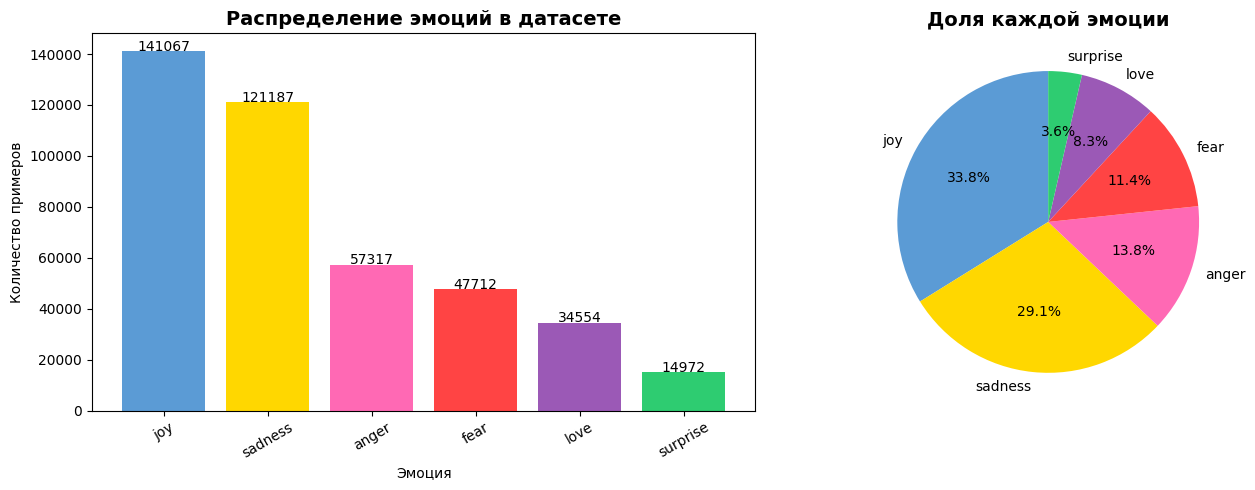


Распределение классов:
emotion
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64


In [10]:
# Маппинг меток
EMOTION_MAP = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
EMOTION_COLORS = ['#5B9BD5', '#FFD700', '#FF69B4', '#FF4444', '#9B59B6', '#2ECC71']

df['emotion'] = df['label'].map(EMOTION_MAP)

# Визуализация распределения классов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['emotion'].value_counts()
axes[0].bar(counts.index, counts.values, color=EMOTION_COLORS[:len(counts)])
axes[0].set_title('Распределение эмоций в датасете', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Эмоция')
axes[0].set_ylabel('Количество примеров')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, colors=EMOTION_COLORS[:len(counts)],
           autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля каждой эмоции', fontsize=14, fontweight='bold')

plt.tight_layout()
save_fig('class_distribution.png')
plt.show()

print("\nРаспределение классов:")
print(counts)

## 3. Предобработка данных

  [saved] artifacts\text_lengths.png


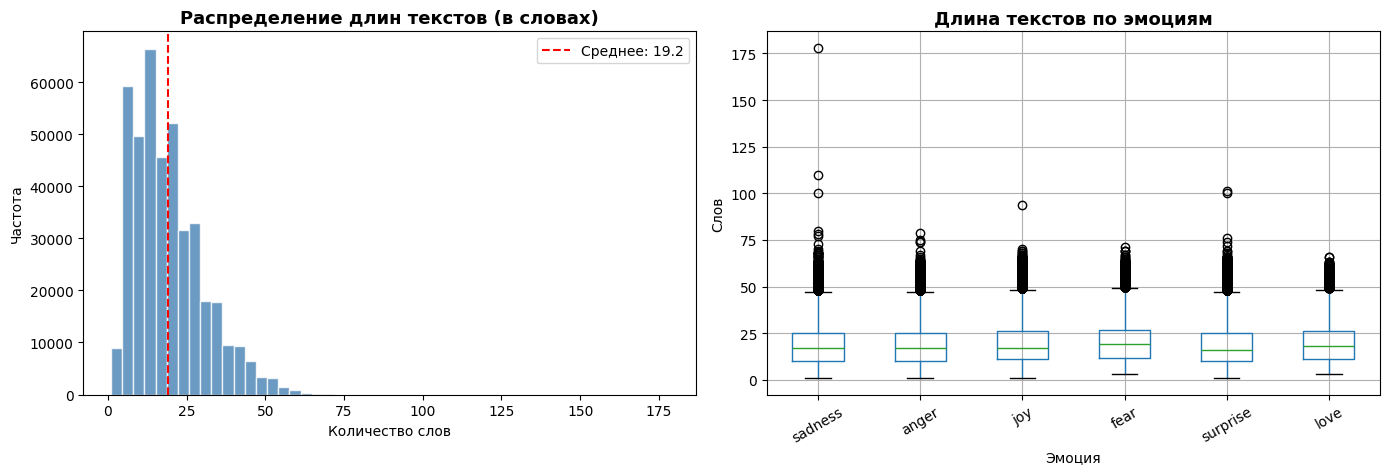

Средняя длина текста: 19.2 слов
Медиана: 17.0 слов
Макс: 178, Мин: 1


In [11]:
import re
from collections import Counter

# Анализ длин текстов
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Распределение длин текстов (в словах)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--',
                label=f'Среднее: {df["text_length"].mean():.1f}')
axes[0].legend()

emotions_sorted = df.groupby('emotion')['text_length'].median().sort_values().index
df.boxplot(column='text_length', by='emotion', ax=axes[1],
           positions=range(len(emotions_sorted)))
axes[1].set_xticklabels(emotions_sorted, rotation=30)
axes[1].set_title('Длина текстов по эмоциям', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Эмоция')
axes[1].set_ylabel('Слов')
plt.suptitle('')

plt.tight_layout()
save_fig('text_lengths.png')
plt.show()

print(f"Средняя длина текста: {df['text_length'].mean():.1f} слов")
print(f"Медиана: {df['text_length'].median():.1f} слов")
print(f"Макс: {df['text_length'].max()}, Мин: {df['text_length'].min()}")

In [12]:
def clean_text(text):
    """Очистка текста"""
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r"[^a-z0-9\s!?.,\'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("Примеры предобработки:")
print("-" * 70)
for i in range(3):
    print(f"Исходный : {df['text'].iloc[i]}")
    print(f"Очищенный: {df['clean_text'].iloc[i]}")
    print(f"Эмоция   : {df['emotion'].iloc[i]}")
    print("-" * 70)

Примеры предобработки:
----------------------------------------------------------------------
Исходный : i just feel really helpless and heavy hearted
Очищенный: i just feel really helpless and heavy hearted
Эмоция   : fear
----------------------------------------------------------------------
Исходный : ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lately started to find myself feeling a bit listless which is never really a good thing
Очищенный: ive enjoyed being able to slouch about relax and unwind and frankly needed it after those last few weeks around the end of uni and the expo i have lately started to find myself feeling a bit listless which is never really a good thing
Эмоция   : sadness
----------------------------------------------------------------------
Исходный : i gave up my internship with the dmrg and am feeling distraught
Очищенный: i gave up my internship with the dmrg

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Convert to numpy arrays explicitly
X = df['clean_text'].values
# Ensure X is a proper 1D array of strings
X = np.array(X, dtype=str)

# Гарантируем целочисленный тип меток (датасет может содержать строки или float)
le = LabelEncoder()
y = le.fit_transform(df['label'].values)
print(f"Классы после LabelEncoder: {le.classes_}")
print(f"Тип y: {y.dtype}")

# Обновляем EMOTION_MAP в соответствии с порядком LabelEncoder
EMOTION_MAP = {i: cls for i, cls in enumerate(le.classes_)}
print(f"EMOTION_MAP: {EMOTION_MAP}")

# Первый сплит: train (80%) и temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Второй сплит: temp разделяем на val (10%) и test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val  : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Классы после LabelEncoder: [0 1 2 3 4 5]
Тип y: int64
EMOTION_MAP: {0: np.int64(0), 1: np.int64(1), 2: np.int64(2), 3: np.int64(3), 4: np.int64(4), 5: np.int64(5)}
Train: 333447 (80.0%)
Val  : 41681 (10.0%)
Test : 41681 (10.0%)


## 4. Подготовка инфраструктуры для RNN-моделей

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# ---- Словарь ----
class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(text.split())
        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"Размер словаря: {len(self.word2idx)} слов")

    def encode(self, text, max_len=64):
        tokens = [self.word2idx.get(w, 1) for w in text.split()[:max_len]]
        tokens += [0] * (max_len - len(tokens))
        return tokens

    def __len__(self):
        return len(self.word2idx)


vocab = Vocabulary(min_freq=2)
vocab.build(X_train)

Используемое устройство: cuda
Размер словаря: 36426 слов


In [29]:
# ---- Dataset ----
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=64):
        self.data = [
            (torch.tensor(vocab.encode(t, max_len), dtype=torch.long),
             torch.tensor(l, dtype=torch.long))
            for t, l in zip(texts, labels)
        ]

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


MAX_LEN    = 64
BATCH_SIZE = 128

train_dataset = EmotionDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset   = EmotionDataset(X_val,   y_val,   vocab, MAX_LEN)
test_dataset  = EmotionDataset(X_test,  y_test,  vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Батчей в train: {len(train_loader)}")

Батчей в train: 2606


In [26]:
# ---- Функции обучения/оценки (общие для RNN-моделей) ----
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        preds = logits.argmax(1)
        correct += (preds == y_batch).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader.dataset), correct / len(loader.dataset), all_preds, all_labels


def train_rnn_model(model, epochs, lr=1e-3, tag='model'):
    """Полный цикл обучения RNN-модели, возвращает историю и лучшие preds."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val  = 0
    best_path = os.path.join(ARTIFACTS_DIR, f'best_{tag}.pt')

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
        scheduler.step(vl_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if vl_acc > best_val:
            best_val = vl_acc
            torch.save(model.state_dict(), best_path)
        print(f"  Epoch {epoch:2d}/{epochs} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    _, _, test_preds, test_true = evaluate(model, test_loader)
    print(f"  Best val acc: {best_val:.4f}")
    return history, np.array(test_preds), np.array(test_true)

print("Инфраструктура готова.")

Инфраструктура готова.


## 5. Модель 1: SimpleRNN (Baseline)

In [30]:
class SimpleRNNClassifier(nn.Module):
    """
    Базовая однонаправленная RNN (Elman RNN).
    Используется как baseline для сравнения с BiLSTM.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_classes=6, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))          # [B, L, E]
        out, hn = self.rnn(emb)                        # out: [B, L, H], hn: [layers, B, H]
        # Берём последний временной шаг последнего слоя
        last_hidden = hn[-1]                           # [B, H]
        return self.fc(self.dropout(last_hidden))


rnn_model = SimpleRNNClassifier(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256,
    num_layers=2, num_classes=6, dropout=0.4
).to(device)

total_rnn = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"Архитектура SimpleRNN:")
print(rnn_model)
print(f"\nОбучаемых параметров: {total_rnn:,}")

Архитектура SimpleRNN:
SimpleRNNClassifier(
  (embedding): Embedding(36426, 128, padding_idx=0)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.4)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Обучаемых параметров: 4,926,598


In [31]:
print("Обучение SimpleRNN...")
rnn_history, rnn_preds, rnn_true = train_rnn_model(rnn_model, epochs=10, lr=1e-3, tag='simplernn')

Обучение SimpleRNN...
  Epoch  1/10 | Train Loss: 1.5842  Acc: 0.3324 | Val Loss: 1.5738  Acc: 0.3389
  Epoch  2/10 | Train Loss: 1.5774  Acc: 0.3358 | Val Loss: 1.5736  Acc: 0.3389
  Epoch  3/10 | Train Loss: 1.5749  Acc: 0.3370 | Val Loss: 1.5722  Acc: 0.3391
  Epoch  4/10 | Train Loss: 1.5737  Acc: 0.3379 | Val Loss: 1.5743  Acc: 0.3380
  Epoch  5/10 | Train Loss: 1.5737  Acc: 0.3376 | Val Loss: 1.5740  Acc: 0.3380
  Epoch  6/10 | Train Loss: 1.5737  Acc: 0.3376 | Val Loss: 1.5723  Acc: 0.3386
  Epoch  7/10 | Train Loss: 1.5728  Acc: 0.3379 | Val Loss: 1.5723  Acc: 0.3392
  Epoch  8/10 | Train Loss: 1.5726  Acc: 0.3381 | Val Loss: 1.5720  Acc: 0.3385
  Epoch  9/10 | Train Loss: 1.5727  Acc: 0.3381 | Val Loss: 1.5720  Acc: 0.3385
  Epoch 10/10 | Train Loss: 1.5724  Acc: 0.3381 | Val Loss: 1.5727  Acc: 0.3378
  Best val acc: 0.3392


  [saved] artifacts\rnn_training.png


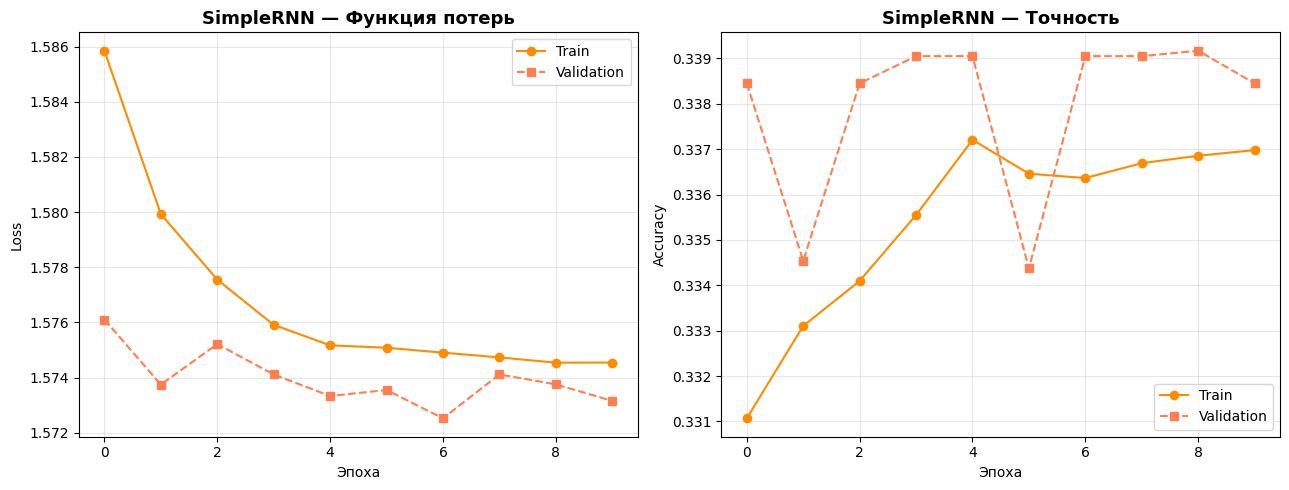

In [17]:
# График обучения SimpleRNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(rnn_history['train_loss'], 'o-', label='Train', color='darkorange')
ax1.plot(rnn_history['val_loss'],   's--', label='Validation', color='coral')
ax1.set_title('SimpleRNN — Функция потерь', fontsize=13, fontweight='bold')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(rnn_history['train_acc'], 'o-', label='Train', color='darkorange')
ax2.plot(rnn_history['val_acc'],   's--', label='Validation', color='coral')
ax2.set_title('SimpleRNN — Точность', fontsize=13, fontweight='bold')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
save_fig('rnn_training.png')
plt.show()

## 6. Модель 2: BiLSTM с механизмом внимания

In [33]:
class BiLSTMClassifier(nn.Module):
    """
    Двунаправленная LSTM с механизмом внимания (Attention).
    Использует контекстный вектор вместо только последнего скрытого состояния.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_classes=6, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout   = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))                        # [B, L, E]
        out, _ = self.lstm(emb)                                      # [B, L, 2H]
        attn_weights = torch.softmax(self.attention(out), dim=1)     # [B, L, 1]
        context = (attn_weights * out).sum(dim=1)                    # [B, 2H]
        return self.fc(context)


lstm_model = BiLSTMClassifier(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256,
    num_layers=2, num_classes=6, dropout=0.4
).to(device)

total_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Архитектура BiLSTM:")
print(lstm_model)
print(f"\nОбучаемых параметров: {total_lstm:,}")

Архитектура BiLSTM:
BiLSTMClassifier(
  (embedding): Embedding(36426, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Обучаемых параметров: 7,096,967


In [34]:
print("Обучение BiLSTM...")
lstm_history, lstm_preds, lstm_true = train_rnn_model(lstm_model, epochs=10, lr=1e-3, tag='bilstm')

Обучение BiLSTM...
  Epoch  1/10 | Train Loss: 0.3413  Acc: 0.8562 | Val Loss: 0.0943  Acc: 0.9381
  Epoch  2/10 | Train Loss: 0.1143  Acc: 0.9333 | Val Loss: 0.0963  Acc: 0.9379
  Epoch  3/10 | Train Loss: 0.1041  Acc: 0.9354 | Val Loss: 0.0914  Acc: 0.9392
  Epoch  4/10 | Train Loss: 0.1005  Acc: 0.9379 | Val Loss: 0.0914  Acc: 0.9393
  Epoch  5/10 | Train Loss: 0.0974  Acc: 0.9383 | Val Loss: 0.0900  Acc: 0.9392
  Epoch  6/10 | Train Loss: 0.0952  Acc: 0.9388 | Val Loss: 0.0888  Acc: 0.9406
  Epoch  7/10 | Train Loss: 0.0932  Acc: 0.9398 | Val Loss: 0.0887  Acc: 0.9407
  Epoch  8/10 | Train Loss: 0.0921  Acc: 0.9406 | Val Loss: 0.0907  Acc: 0.9406
  Epoch  9/10 | Train Loss: 0.0908  Acc: 0.9409 | Val Loss: 0.0886  Acc: 0.9412
  Epoch 10/10 | Train Loss: 0.0898  Acc: 0.9406 | Val Loss: 0.0892  Acc: 0.9407
  Best val acc: 0.9412


  [saved] artifacts\lstm_training.png


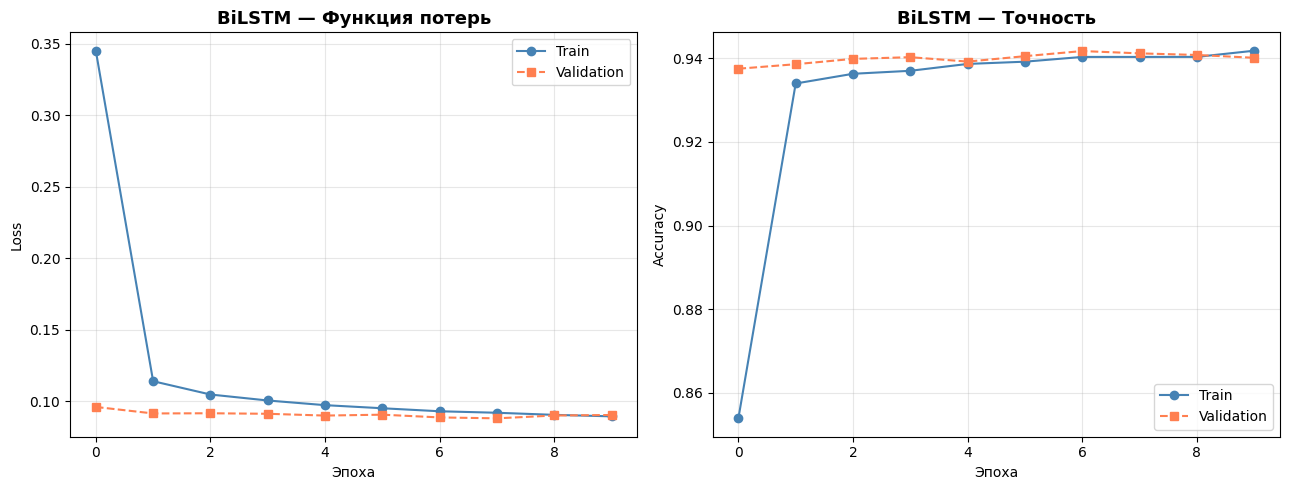

In [20]:
# График обучения BiLSTM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(lstm_history['train_loss'], 'o-', label='Train', color='steelblue')
ax1.plot(lstm_history['val_loss'],   's--', label='Validation', color='coral')
ax1.set_title('BiLSTM — Функция потерь', fontsize=13, fontweight='bold')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(lstm_history['train_acc'], 'o-', label='Train', color='steelblue')
ax2.plot(lstm_history['val_acc'],   's--', label='Validation', color='coral')
ax2.set_title('BiLSTM — Точность', fontsize=13, fontweight='bold')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
save_fig('lstm_training.png')
plt.show()

## 7. Сравнение SimpleRNN vs BiLSTM

In [35]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

emotion_names = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP.keys())]

print("=" * 60)
print("РЕЗУЛЬТАТЫ SimpleRNN на тестовой выборке:")
print("=" * 60)
print(classification_report(rnn_true, rnn_preds, target_names=emotion_names))

print("=" * 60)
print("РЕЗУЛЬТАТЫ BiLSTM на тестовой выборке:")
print("=" * 60)
print(classification_report(lstm_true, lstm_preds, target_names=emotion_names))

РЕЗУЛЬТАТЫ SimpleRNN на тестовой выборке:


TypeError: object of type 'numpy.int64' has no len()

  [saved] artifacts\rnn_vs_bilstm_learning_curves.png


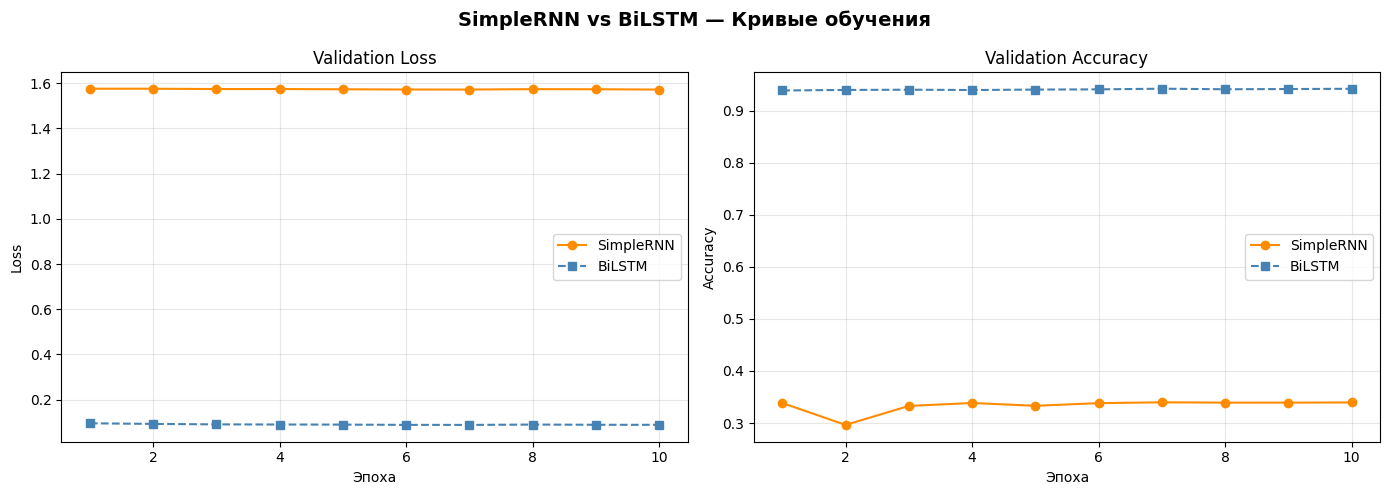

In [ ]:
# ── 7.1 Кривые обучения: SimpleRNN vs BiLSTM ──
epochs_range = range(1, len(rnn_history['val_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SimpleRNN vs BiLSTM — Кривые обучения', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, rnn_history['val_loss'],  'o-', color='darkorange',  label='SimpleRNN')
axes[0].plot(epochs_range, lstm_history['val_loss'], 's--', color='steelblue',  label='BiLSTM')
axes[0].set_title('Validation Loss', fontsize=12)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, rnn_history['val_acc'],  'o-', color='darkorange',  label='SimpleRNN')
axes[1].plot(epochs_range, lstm_history['val_acc'], 's--', color='steelblue',  label='BiLSTM')
axes[1].set_title('Validation Accuracy', fontsize=12)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
save_fig('rnn_vs_bilstm_learning_curves.png')
plt.show()

  [saved] artifacts\rnn_vs_bilstm_metrics.png


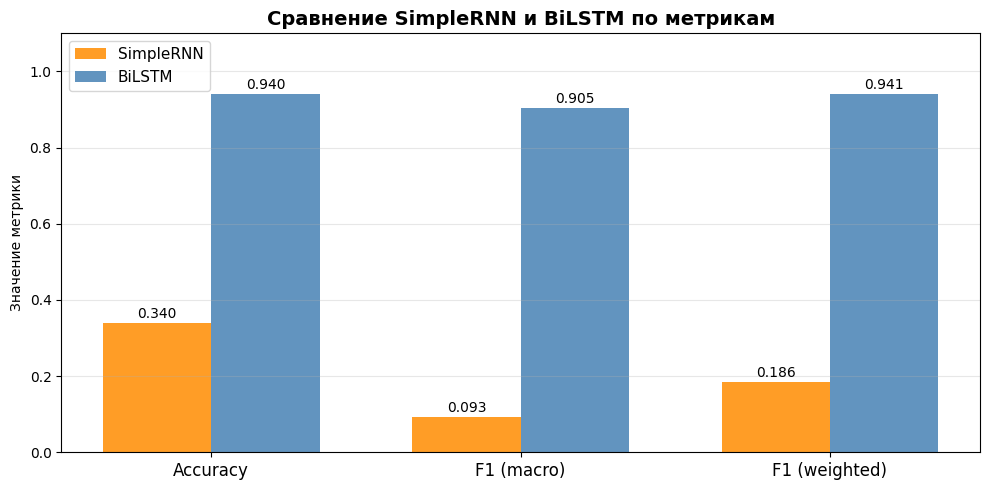

In [ ]:
# ── 7.2 Сводные метрики: SimpleRNN vs BiLSTM ──
rnn_metrics  = {
    'Accuracy':      accuracy_score(rnn_true, rnn_preds),
    'F1 (macro)':    f1_score(rnn_true, rnn_preds,  average='macro'),
    'F1 (weighted)': f1_score(rnn_true, rnn_preds,  average='weighted'),
}
lstm_metrics = {
    'Accuracy':      accuracy_score(lstm_true, lstm_preds),
    'F1 (macro)':    f1_score(lstm_true, lstm_preds, average='macro'),
    'F1 (weighted)': f1_score(lstm_true, lstm_preds, average='weighted'),
}

metric_names = list(rnn_metrics.keys())
x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, list(rnn_metrics.values()),  width,
               label='SimpleRNN', color='darkorange', alpha=0.85)
bars2 = ax.bar(x + width/2, list(lstm_metrics.values()), width,
               label='BiLSTM',    color='steelblue',   alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Сравнение SimpleRNN и BiLSTM по метрикам', fontsize=14, fontweight='bold')
ax.set_ylabel('Значение метрики')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('rnn_vs_bilstm_metrics.png')
plt.show()

  [saved] artifacts\rnn_vs_bilstm_f1_per_class.png


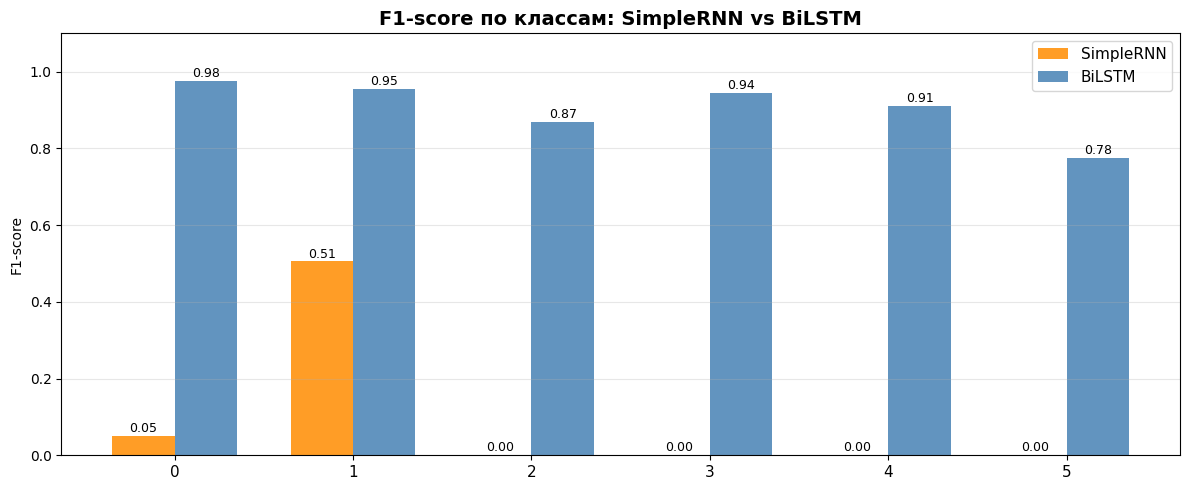

In [ ]:
# ── 7.3 F1 по классам: SimpleRNN vs BiLSTM ──
rnn_f1_cls  = f1_score(rnn_true,  rnn_preds,  average=None)
lstm_f1_cls = f1_score(lstm_true, lstm_preds, average=None)

x = np.arange(6)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, rnn_f1_cls,  width, label='SimpleRNN', color='darkorange', alpha=0.85)
ax.bar(x + width/2, lstm_f1_cls, width, label='BiLSTM',    color='steelblue',  alpha=0.85)

for i, (r, l) in enumerate(zip(rnn_f1_cls, lstm_f1_cls)):
    ax.text(i - width/2, r + 0.01, f'{r:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, l + 0.01, f'{l:.2f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(emotion_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('F1-score по классам: SimpleRNN vs BiLSTM', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-score')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('rnn_vs_bilstm_f1_per_class.png')
plt.show()

  [saved] artifacts\rnn_vs_bilstm_confusion.png


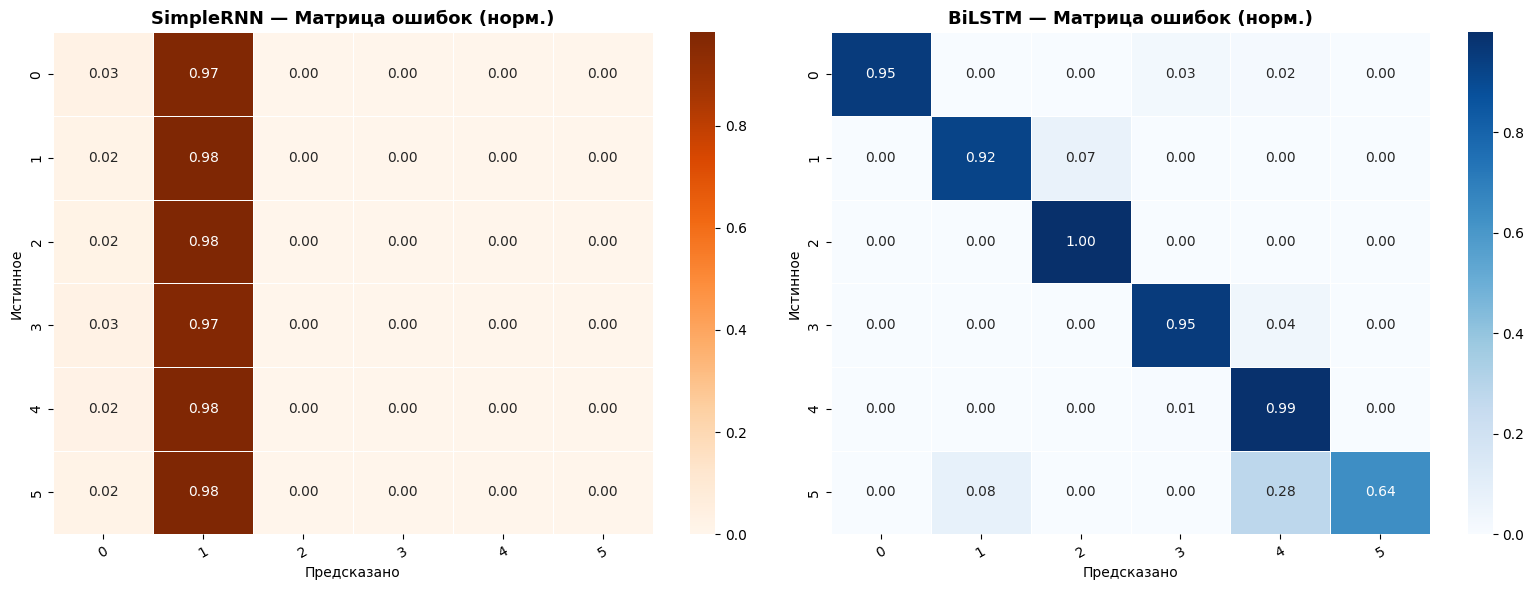


{'Характеристика':<28} {'SimpleRNN':>12} {'BiLSTM':>12}
-------------------------------------------------------
Параметров                      4,926,598    7,096,967
Test Accuracy                      0.3401       0.9402
F1 macro                           0.0926       0.9050
F1 weighted                        0.1856       0.9407


In [ ]:
# ── 7.4 Матрицы ошибок ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, true, title, cmap in [
    (axes[0], rnn_preds,  rnn_true,  'SimpleRNN', 'Oranges'),
    (axes[1], lstm_preds, lstm_true, 'BiLSTM',    'Blues'),
]:
    cm = confusion_matrix(true, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=emotion_names, yticklabels=emotion_names,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{title} — Матрица ошибок (норм.)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинное')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
save_fig('rnn_vs_bilstm_confusion.png')
plt.show()

# Таблица итогов
print("\n{'Характеристика':<28} {'SimpleRNN':>12} {'BiLSTM':>12}")
print("-" * 55)
print(f"{'Параметров':<28} {total_rnn:>12,} {total_lstm:>12,}")
print(f"{'Test Accuracy':<28} {rnn_metrics['Accuracy']:>12.4f} {lstm_metrics['Accuracy']:>12.4f}")
print(f"{'F1 macro':<28} {rnn_metrics['F1 (macro)']:>12.4f} {lstm_metrics['F1 (macro)']:>12.4f}")
print(f"{'F1 weighted':<28} {rnn_metrics['F1 (weighted)']:>12.4f} {lstm_metrics['F1 (weighted)']:>12.4f}")

## 8. Эксперименты с BiLSTM

### 8.1 Эксперимент BiLSTM-1: Влияние размерности эмбеддингов и скрытого слоя

In [ ]:
"""
Гипотеза: более высокая размерность эмбеддингов и hidden_dim повышает качество,
но увеличивает риск переобучения и время обучения.
"""

BILSTM_EXP1_CONFIGS = [
    {'embed_dim':  64, 'hidden_dim': 128, 'label': 'E64-H128'},
    {'embed_dim': 128, 'hidden_dim': 128, 'label': 'E128-H128'},
    {'embed_dim': 128, 'hidden_dim': 256, 'label': 'E128-H256'},  # baseline
    
]

bilstm_exp1_results = []
EXP_EPOCHS = 3  # Сокращённое число эпох для экспериментов

for cfg in BILSTM_EXP1_CONFIGS:
    print(f"\n--- BiLSTM Exp1: {cfg['label']} ---")
    model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=cfg['embed_dim'],
        hidden_dim=cfg['hidden_dim'],
        num_layers=2, num_classes=6, dropout=0.4
    ).to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    hist, preds, true = train_rnn_model(
        model, epochs=EXP_EPOCHS, lr=1e-3,
        tag=f"bilstm_exp1_{cfg['label']}"
    )
    bilstm_exp1_results.append({
        'label':     cfg['label'],
        'params':    params,
        'test_acc':  accuracy_score(true, preds),
        'f1_macro':  f1_score(true, preds, average='macro'),
        'history':   hist,
    })

print("\nЭксперимент BiLSTM-1 завершён.")


--- BiLSTM Exp1: E64-H128 ---
  Epoch  1/7 | Train Loss: 0.5753  Acc: 0.7639 | Val Loss: 0.1065  Acc: 0.9341
  Epoch  2/7 | Train Loss: 0.1529  Acc: 0.9230 | Val Loss: 0.0955  Acc: 0.9380
  Epoch  3/7 | Train Loss: 0.1226  Acc: 0.9316 | Val Loss: 0.0924  Acc: 0.9385
  Epoch  4/7 | Train Loss: 0.1116  Acc: 0.9346 | Val Loss: 0.0916  Acc: 0.9391
  Epoch  5/7 | Train Loss: 0.1050  Acc: 0.9362 | Val Loss: 0.0908  Acc: 0.9400
  Epoch  6/7 | Train Loss: 0.1015  Acc: 0.9370 | Val Loss: 0.0902  Acc: 0.9395
  Epoch  7/7 | Train Loss: 0.0986  Acc: 0.9382 | Val Loss: 0.0901  Acc: 0.9405
  Best val acc: 0.9405

--- BiLSTM Exp1: E128-H128 ---
  Epoch  1/7 | Train Loss: 0.4027  Acc: 0.8353 | Val Loss: 0.0980  Acc: 0.9378
  Epoch  2/7 | Train Loss: 0.1194  Acc: 0.9326 | Val Loss: 0.0916  Acc: 0.9387
  Epoch  3/7 | Train Loss: 0.1065  Acc: 0.9357 | Val Loss: 0.0907  Acc: 0.9405
  Epoch  4/7 | Train Loss: 0.1010  Acc: 0.9377 | Val Loss: 0.0900  Acc: 0.9398
  Epoch  5/7 | Train Loss: 0.0971  Acc: 0.938

  [saved] artifacts\bilstm_exp1_dim.png


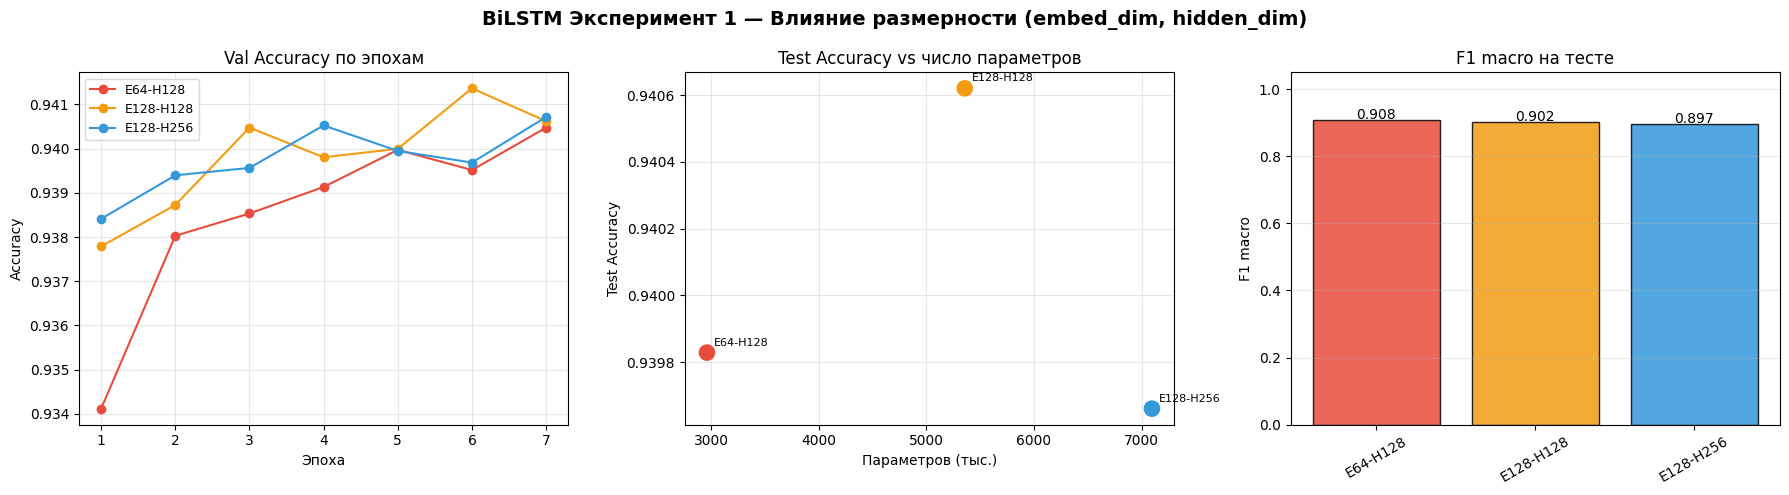


Итоги Эксперимента BiLSTM-1:
Конфиг            Параметров   Test Acc   F1 macro
--------------------------------------------------
E64-H128           2,959,111     0.9398     0.9082
E128-H128          5,355,911     0.9406     0.9024
E128-H256          7,096,967     0.9397     0.8975


In [ ]:
# Графики Эксперимента BiLSTM-1
colors_exp1 = ['#e74c3c', '#f39c12', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BiLSTM Эксперимент 1 — Влияние размерности (embed_dim, hidden_dim)',
             fontsize=14, fontweight='bold')

# (a) Val Accuracy по эпохам
for res, c in zip(bilstm_exp1_results, colors_exp1):
    axes[0].plot(range(1, EXP_EPOCHS + 1), res['history']['val_acc'],
                 'o-', color=c, label=res['label'])
axes[0].set_title('Val Accuracy по эпохам', fontsize=12)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# (b) Test Accuracy vs число параметров
params_k   = [r['params'] / 1e3 for r in bilstm_exp1_results]
test_accs  = [r['test_acc'] for r in bilstm_exp1_results]
labels_exp = [r['label'] for r in bilstm_exp1_results]
axes[1].scatter(params_k, test_accs, s=120, c=colors_exp1, zorder=5)
for i, lbl in enumerate(labels_exp):
    axes[1].annotate(lbl, (params_k[i], test_accs[i]),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].set_title('Test Accuracy vs число параметров', fontsize=12)
axes[1].set_xlabel('Параметров (тыс.)'); axes[1].set_ylabel('Test Accuracy')
axes[1].grid(alpha=0.3)

# (c) Гистограмма F1 macro
f1_scores = [r['f1_macro'] for r in bilstm_exp1_results]
bars = axes[2].bar(labels_exp, f1_scores, color=colors_exp1, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, f1_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontsize=10)
axes[2].set_title('F1 macro на тесте', fontsize=12)
axes[2].set_ylabel('F1 macro')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('bilstm_exp1_dim.png')
plt.show()

print("\nИтоги Эксперимента BiLSTM-1:")
print(f"{'Конфиг':<15} {'Параметров':>12} {'Test Acc':>10} {'F1 macro':>10}")
print("-" * 50)
for r in bilstm_exp1_results:
    print(f"{r['label']:<15} {r['params']:>12,} {r['test_acc']:>10.4f} {r['f1_macro']:>10.4f}")

### 8.2 Эксперимент BiLSTM-2: Влияние dropout

In [ ]:
"""
Гипотеза: слишком маленький dropout → переобучение,
слишком большой → недообучение. Существует оптимальное значение.
"""

DROPOUT_VALUES = [0.1, 0.3, 0.5]
bilstm_exp2_results = []

for dp in DROPOUT_VALUES:
    print(f"\n--- BiLSTM Exp2: dropout={dp} ---")
    model = BiLSTMClassifier(
        vocab_size=len(vocab), embed_dim=128, hidden_dim=256,
        num_layers=2, num_classes=6, dropout=dp
    ).to(device)

    hist, preds, true = train_rnn_model(
        model, epochs=EXP_EPOCHS, lr=1e-3,
        tag=f"bilstm_exp2_dp{int(dp*10)}"
    )
    # Считаем gap между train и val для оценки переобучения
    train_acc_last = hist['train_acc'][-1]
    val_acc_last   = hist['val_acc'][-1]
    bilstm_exp2_results.append({
        'dropout':   dp,
        'test_acc':  accuracy_score(true, preds),
        'f1_macro':  f1_score(true, preds, average='macro'),
        'overfit_gap': train_acc_last - val_acc_last,
        'history':   hist,
    })

print("\nЭксперимент BiLSTM-2 завершён.")


--- BiLSTM Exp2: dropout=0.1 ---
  Epoch  1/7 | Train Loss: 0.2311  Acc: 0.8915 | Val Loss: 0.0939  Acc: 0.9383
  Epoch  2/7 | Train Loss: 0.0953  Acc: 0.9393 | Val Loss: 0.0905  Acc: 0.9409
  Epoch  3/7 | Train Loss: 0.0909  Acc: 0.9401 | Val Loss: 0.0901  Acc: 0.9403
  Epoch  4/7 | Train Loss: 0.0879  Acc: 0.9415 | Val Loss: 0.0886  Acc: 0.9407
  Epoch  5/7 | Train Loss: 0.0851  Acc: 0.9426 | Val Loss: 0.0901  Acc: 0.9411
  Epoch  6/7 | Train Loss: 0.0828  Acc: 0.9437 | Val Loss: 0.0931  Acc: 0.9419
  Epoch  7/7 | Train Loss: 0.0811  Acc: 0.9443 | Val Loss: 0.0950  Acc: 0.9401
  Best val acc: 0.9419

--- BiLSTM Exp2: dropout=0.3 ---
  Epoch  1/7 | Train Loss: 0.2874  Acc: 0.8716 | Val Loss: 0.0936  Acc: 0.9397
  Epoch  2/7 | Train Loss: 0.1039  Acc: 0.9362 | Val Loss: 0.0928  Acc: 0.9399
  Epoch  3/7 | Train Loss: 0.0977  Acc: 0.9384 | Val Loss: 0.0902  Acc: 0.9399
  Epoch  4/7 | Train Loss: 0.0942  Acc: 0.9395 | Val Loss: 0.0891  Acc: 0.9393
  Epoch  5/7 | Train Loss: 0.0915  Acc: 

  [saved] artifacts\bilstm_exp2_dropout.png


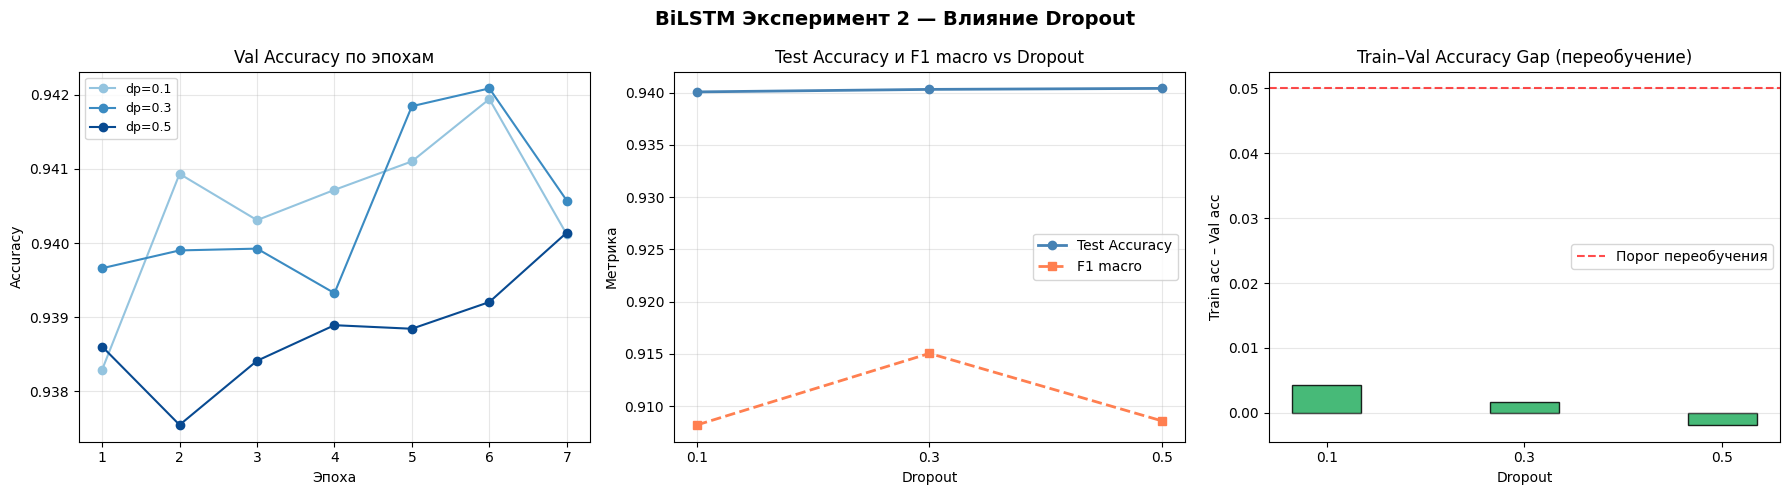


Итоги Эксперимента BiLSTM-2:
Dropout      Test Acc   F1 macro  Overfit Gap
---------------------------------------------
0.1            0.9401     0.9082       0.0042
0.3            0.9403     0.9150       0.0017
0.5            0.9404     0.9086      -0.0019


In [ ]:
# Графики Эксперимента BiLSTM-2
cmap_blues = plt.cm.Blues(np.linspace(0.4, 0.9, len(DROPOUT_VALUES)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BiLSTM Эксперимент 2 — Влияние Dropout',
             fontsize=14, fontweight='bold')

# (a) Val Accuracy по эпохам
for res, c in zip(bilstm_exp2_results, cmap_blues):
    axes[0].plot(range(1, EXP_EPOCHS + 1), res['history']['val_acc'],
                 'o-', color=c, label=f"dp={res['dropout']}")
axes[0].set_title('Val Accuracy по эпохам', fontsize=12)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# (b) Test Accuracy vs dropout
dp_vals  = [r['dropout']  for r in bilstm_exp2_results]
acc_vals = [r['test_acc'] for r in bilstm_exp2_results]
f1_vals  = [r['f1_macro'] for r in bilstm_exp2_results]
axes[1].plot(dp_vals, acc_vals, 'o-', color='steelblue',  label='Test Accuracy', linewidth=2)
axes[1].plot(dp_vals, f1_vals,  's--', color='coral',      label='F1 macro',      linewidth=2)
axes[1].set_title('Test Accuracy и F1 macro vs Dropout', fontsize=12)
axes[1].set_xlabel('Dropout'); axes[1].set_ylabel('Метрика')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(dp_vals)

# (c) Overfitting gap
gap_vals = [r['overfit_gap'] for r in bilstm_exp2_results]
bar_colors = ['#e74c3c' if g > 0.05 else '#27ae60' for g in gap_vals]
axes[2].bar(dp_vals, gap_vals, width=0.07, color=bar_colors, edgecolor='black', alpha=0.85)
axes[2].axhline(0.05, color='red', linestyle='--', alpha=0.7, label='Порог переобучения')
axes[2].set_title('Train–Val Accuracy Gap (переобучение)', fontsize=12)
axes[2].set_xlabel('Dropout'); axes[2].set_ylabel('Train acc – Val acc')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
axes[2].set_xticks(dp_vals)

plt.tight_layout()
save_fig('bilstm_exp2_dropout.png')
plt.show()

print("\nИтоги Эксперимента BiLSTM-2:")
print(f"{'Dropout':<10} {'Test Acc':>10} {'F1 macro':>10} {'Overfit Gap':>12}")
print("-" * 45)
for r in bilstm_exp2_results:
    print(f"{r['dropout']:<10.1f} {r['test_acc']:>10.4f} {r['f1_macro']:>10.4f} {r['overfit_gap']:>12.4f}")

## 9. Модель 3: Трансформер (DistilBERT)

In [17]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset as TorchDataset

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f"Токенизатор загружен: {MODEL_NAME}")


class BertEmotionDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }


# Используем подмножество для ускорения (20k train, 2k val/test)
N_TRAIN, N_EVAL = 20000, 2000
idx_tr = np.random.choice(len(X_train), min(N_TRAIN, len(X_train)), replace=False)
idx_vl = np.random.choice(len(X_val),   min(N_EVAL,  len(X_val)),   replace=False)
idx_ts = np.random.choice(len(X_test),  min(N_EVAL,  len(X_test)),  replace=False)

bert_train = BertEmotionDataset(X_train[idx_tr], y_train[idx_tr], tokenizer)
bert_val   = BertEmotionDataset(X_val[idx_vl],   y_val[idx_vl],   tokenizer)
bert_test  = BertEmotionDataset(X_test[idx_ts],  y_test[idx_ts],  tokenizer)

bert_train_loader = DataLoader(bert_train, batch_size=32, shuffle=True)
bert_val_loader   = DataLoader(bert_val,   batch_size=64)
bert_test_loader  = DataLoader(bert_test,  batch_size=64)

print(f"Train: {len(bert_train)}, Val: {len(bert_val)}, Test: {len(bert_test)}")

Токенизатор загружен: distilbert-base-uncased
Train: 20000, Val: 2000, Test: 2000


In [18]:
def get_bert_model(frozen_layers=4):
    """Создаёт DistilBERT с заморозкой первых frozen_layers трансформерных слоёв."""
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=6
    ).to(device)
    # DistilBERT имеет 6 трансформерных слоёв
    for name, param in model.distilbert.transformer.layer[:frozen_layers].named_parameters():
        param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Заморожено слоёв: {frozen_layers}/6 | "
          f"Обучаемых: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")
    return model


def train_bert_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct = 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += outputs.loss.item() * len(labels)
        correct    += (outputs.logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


@torch.no_grad()
def eval_bert(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += outputs.loss.item() * len(labels)
        preds = outputs.logits.argmax(1)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), correct / len(loader.dataset), all_preds, all_labels


def train_bert_full(model, epochs, lr, tag='bert'):
    optimizer   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(bert_train_loader) * epochs
    scheduler   = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=total_steps
    )
    history  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val = 0
    best_path = os.path.join(ARTIFACTS_DIR, f'best_{tag}.pt')

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_bert_epoch(model, bert_train_loader, optimizer, scheduler)
        vl_loss, vl_acc, _, _ = eval_bert(model, bert_val_loader)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if vl_acc > best_val:
            best_val = vl_acc
            torch.save(model.state_dict(), best_path)
        print(f"  Epoch {epoch}/{epochs} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    _, _, test_preds, test_true = eval_bert(model, bert_test_loader)
    print(f"  Best val acc: {best_val:.4f}")
    return history, np.array(test_preds), np.array(test_true)


print("Утилиты DistilBERT готовы.")

Утилиты DistilBERT готовы.


In [38]:
# Базовая DistilBERT (4 замороженных слоя, lr=2e-5)
print("Обучение DistilBERT (baseline)...")
bert_model = get_bert_model(frozen_layers=4)
bert_history, bert_preds, bert_true = train_bert_full(bert_model, epochs=4, lr=2e-5, tag='bert_base')

print("\n=" * 60)
print("РЕЗУЛЬТАТЫ DistilBERT на тестовой выборке:")
print("=" * 60)
print(classification_report(bert_true, bert_preds, target_names=emotion_names))

Обучение DistilBERT (baseline)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8529.00it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 4/6 | Обучаемых: 38,606,598 / 66,958,086 (57.7%)
  Epoch 1/4 | Train Loss: 0.7740  Acc: 0.7293 | Val Loss: 0.3642  Acc: 0.8715
  Epoch 2/4 | Train Loss: 0.3019  Acc: 0.8923 | Val Loss: 0.2680  Acc: 0.8995
  Epoch 3/4 | Train Loss: 0.2104  Acc: 0.9182 | Val Loss: 0.2586  Acc: 0.9015
  Epoch 4/4 | Train Loss: 0.1729  Acc: 0.9311 | Val Loss: 0.2532  Acc: 0.9040
  Best val acc: 0.9040

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
РЕЗУЛЬТАТЫ DistilBERT на тестовой выборке:


TypeError: object of type 'numpy.int64' has no len()

  [saved] artifacts\bert_training.png


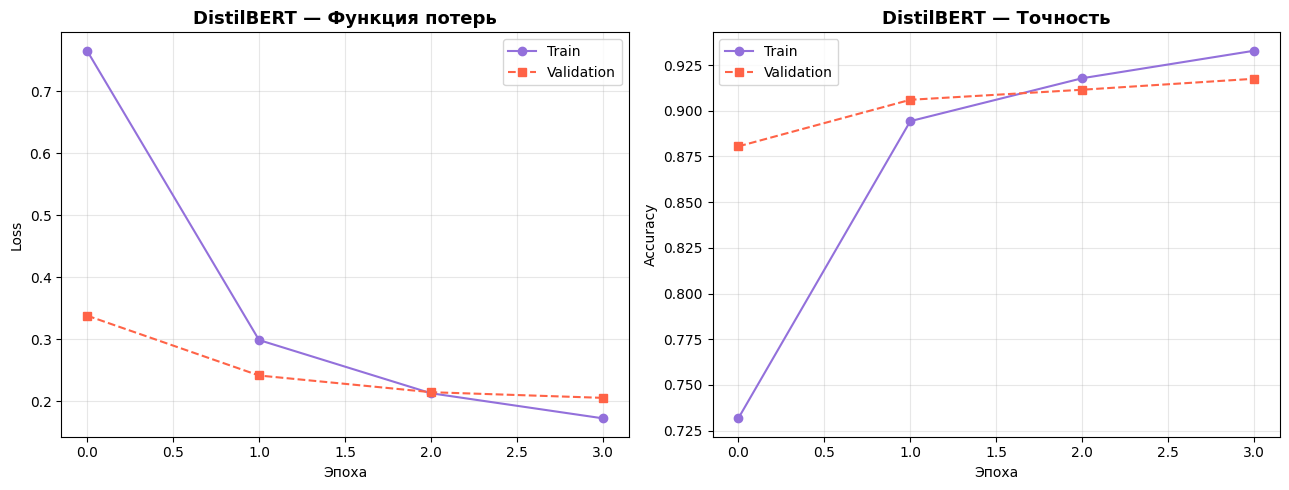

In [ ]:
# График обучения DistilBERT baseline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(bert_history['train_loss'], 'o-', label='Train', color='mediumpurple')
ax1.plot(bert_history['val_loss'],   's--', label='Validation', color='tomato')
ax1.set_title('DistilBERT — Функция потерь', fontsize=13, fontweight='bold')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(bert_history['train_acc'], 'o-', label='Train', color='mediumpurple')
ax2.plot(bert_history['val_acc'],   's--', label='Validation', color='tomato')
ax2.set_title('DistilBERT — Точность', fontsize=13, fontweight='bold')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
save_fig('bert_training.png')
plt.show()

## 10. Эксперименты с DistilBERT

### 10.1 Эксперимент DistilBERT-1: Влияние learning rate

In [19]:
"""
Гипотеза: слишком высокий LR разрушает предобученные веса (catastrophic forgetting),
слишком низкий — слишком медленная сходимость.
Для fine-tuning трансформеров оптимальный диапазон: 1e-5 … 5e-5.
"""

BERT_LR_VALUES = [1e-5, 5e-5, 1e-4]
BERT_EXP_EPOCHS = 3  # сокращённо для экспериментов
bert_exp1_results = []

for lr in BERT_LR_VALUES:
    print(f"\n--- DistilBERT Exp1: lr={lr:.0e} ---")
    model = get_bert_model(frozen_layers=4)
    hist, preds, true = train_bert_full(
        model, epochs=BERT_EXP_EPOCHS, lr=lr,
        tag=f"bert_exp1_lr{str(lr).replace('.','')}"
    )
    bert_exp1_results.append({
        'lr':       lr,
        'test_acc': accuracy_score(true, preds),
        'f1_macro': f1_score(true, preds, average='macro'),
        'history':  hist,
    })

print("\nЭксперимент DistilBERT-1 завершён.")


--- DistilBERT Exp1: lr=1e-05 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7998.90it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 4/6 | Обучаемых: 38,606,598 / 66,958,086 (57.7%)
  Epoch 1/3 | Train Loss: 1.0142  Acc: 0.6401 | Val Loss: 0.5685  Acc: 0.8065
  Epoch 2/3 | Train Loss: 0.5013  Acc: 0.8310 | Val Loss: 0.3980  Acc: 0.8625
  Epoch 3/3 | Train Loss: 0.3869  Acc: 0.8690 | Val Loss: 0.3582  Acc: 0.8730
  Best val acc: 0.8730

--- DistilBERT Exp1: lr=5e-05 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8082.44it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 4/6 | Обучаемых: 38,606,598 / 66,958,086 (57.7%)
  Epoch 1/3 | Train Loss: 0.5229  Acc: 0.8147 | Val Loss: 0.2514  Acc: 0.9075
  Epoch 2/3 | Train Loss: 0.1877  Acc: 0.9254 | Val Loss: 0.2368  Acc: 0.9090
  Epoch 3/3 | Train Loss: 0.1254  Acc: 0.9461 | Val Loss: 0.2433  Acc: 0.9115
  Best val acc: 0.9115

--- DistilBERT Exp1: lr=1e-04 ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7697.52it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 4/6 | Обучаемых: 38,606,598 / 66,958,086 (57.7%)
  Epoch 1/3 | Train Loss: 0.4292  Acc: 0.8477 | Val Loss: 0.2271  Acc: 0.9135
  Epoch 2/3 | Train Loss: 0.1454  Acc: 0.9346 | Val Loss: 0.2055  Acc: 0.9100
  Epoch 3/3 | Train Loss: 0.0954  Acc: 0.9539 | Val Loss: 0.2177  Acc: 0.9180
  Best val acc: 0.9180

Эксперимент DistilBERT-1 завершён.


  [saved] artifacts\bert_exp1_lr.png


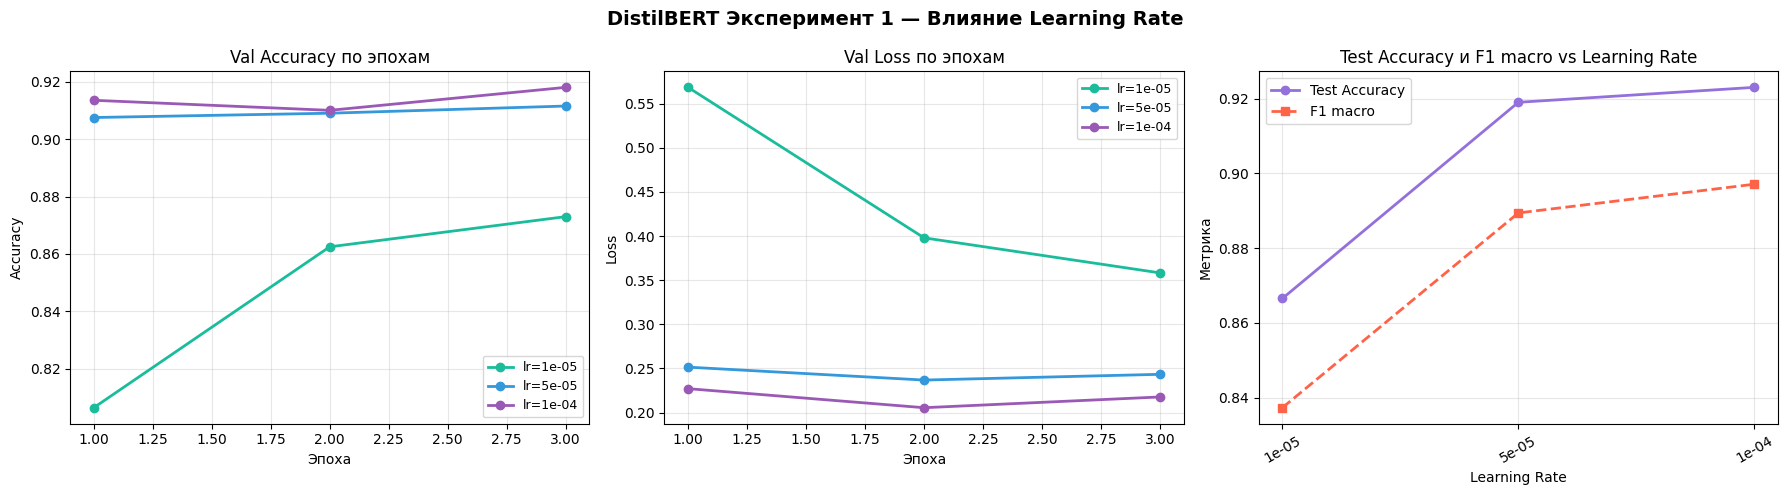


Итоги Эксперимента DistilBERT-1:
LR             Test Acc   F1 macro
-----------------------------------
1e-05            0.8665     0.8373
5e-05            0.9190     0.8894
1e-04            0.9230     0.8971


In [20]:
# Графики Эксперимента DistilBERT-1
colors_bert1 = ['#1abc9c', '#3498db', '#9b59b6']
lr_labels    = [f'{lr:.0e}' for lr in BERT_LR_VALUES]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DistilBERT Эксперимент 1 — Влияние Learning Rate',
             fontsize=14, fontweight='bold')

# (a) Val Accuracy по эпохам
for res, c, lbl in zip(bert_exp1_results, colors_bert1, lr_labels):
    axes[0].plot(range(1, BERT_EXP_EPOCHS + 1), res['history']['val_acc'],
                 'o-', color=c, label=f'lr={lbl}', linewidth=2)
axes[0].set_title('Val Accuracy по эпохам', fontsize=12)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# (b) Val Loss по эпохам
for res, c, lbl in zip(bert_exp1_results, colors_bert1, lr_labels):
    axes[1].plot(range(1, BERT_EXP_EPOCHS + 1), res['history']['val_loss'],
                 'o-', color=c, label=f'lr={lbl}', linewidth=2)
axes[1].set_title('Val Loss по эпохам', fontsize=12)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# (c) Test Accuracy и F1 vs LR
test_accs = [r['test_acc'] for r in bert_exp1_results]
f1_macros = [r['f1_macro'] for r in bert_exp1_results]
x_pos = np.arange(len(BERT_LR_VALUES))
axes[2].plot(x_pos, test_accs, 'o-', color='mediumpurple', label='Test Accuracy', linewidth=2)
axes[2].plot(x_pos, f1_macros, 's--', color='tomato',      label='F1 macro',      linewidth=2)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(lr_labels, rotation=30)
axes[2].set_title('Test Accuracy и F1 macro vs Learning Rate', fontsize=12)
axes[2].set_xlabel('Learning Rate'); axes[2].set_ylabel('Метрика')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
save_fig('bert_exp1_lr.png')
plt.show()

print("\nИтоги Эксперимента DistilBERT-1:")
print(f"{'LR':<12} {'Test Acc':>10} {'F1 macro':>10}")
print("-" * 35)
for r, lbl in zip(bert_exp1_results, lr_labels):
    print(f"{lbl:<12} {r['test_acc']:>10.4f} {r['f1_macro']:>10.4f}")

### 10.2 Эксперимент DistilBERT-2: Влияние количества размороженных слоёв

In [21]:
"""
Гипотеза: разморозка большего числа трансформерных слоёв позволяет лучше
адаптировать предобученные представления к задаче,
но требует больше памяти и риск catastrophic forgetting возрастает.
DistilBERT имеет 6 трансформерных слоёв (0..5).
"""

FROZEN_LAYER_VALUES = [6,3,0]  # 6=полная заморозка, 0=полная разморозка
bert_exp2_results = []

for frozen in FROZEN_LAYER_VALUES:
    unfrozen = 6 - frozen
    print(f"\n--- DistilBERT Exp2: frozen={frozen} (unfrozen={unfrozen}) ---")
    model = get_bert_model(frozen_layers=frozen)
    hist, preds, true = train_bert_full(
        model, epochs=BERT_EXP_EPOCHS, lr=2e-5,
        tag=f"bert_exp2_frozen{frozen}"
    )
    bert_exp2_results.append({
        'frozen':    frozen,
        'unfrozen':  unfrozen,
        'test_acc':  accuracy_score(true, preds),
        'f1_macro':  f1_score(true, preds, average='macro'),
        'history':   hist,
    })

print("\nЭксперимент DistilBERT-2 завершён.")


--- DistilBERT Exp2: frozen=6 (unfrozen=0) ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7452.04it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 6/6 | Обучаемых: 24,430,854 / 66,958,086 (36.5%)
  Epoch 1/3 | Train Loss: 1.4764  Acc: 0.4622 | Val Loss: 1.2763  Acc: 0.5540
  Epoch 2/3 | Train Loss: 1.1878  Acc: 0.5628 | Val Loss: 1.0847  Acc: 0.5835
  Epoch 3/3 | Train Loss: 1.0558  Acc: 0.5976 | Val Loss: 1.0155  Acc: 0.6075
  Best val acc: 0.6075

--- DistilBERT Exp2: frozen=3 (unfrozen=3) ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8051.57it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 3/6 | Обучаемых: 45,694,470 / 66,958,086 (68.2%)
  Epoch 1/3 | Train Loss: 0.6686  Acc: 0.7686 | Val Loss: 0.3190  Acc: 0.8855
  Epoch 2/3 | Train Loss: 0.2475  Acc: 0.9097 | Val Loss: 0.2469  Acc: 0.9050
  Epoch 3/3 | Train Loss: 0.1751  Acc: 0.9311 | Val Loss: 0.2357  Acc: 0.9055
  Best val acc: 0.9055

--- DistilBERT Exp2: frozen=0 (unfrozen=6) ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7850.68it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Заморожено слоёв: 0/6 | Обучаемых: 66,958,086 / 66,958,086 (100.0%)
  Epoch 1/3 | Train Loss: 0.5622  Acc: 0.8040 | Val Loss: 0.2100  Acc: 0.9220
  Epoch 2/3 | Train Loss: 0.1634  Acc: 0.9347 | Val Loss: 0.1762  Acc: 0.9260
  Epoch 3/3 | Train Loss: 0.1079  Acc: 0.9517 | Val Loss: 0.1801  Acc: 0.9275
  Best val acc: 0.9275

Эксперимент DistilBERT-2 завершён.


  [saved] artifacts\bert_exp2_frozen_layers.png


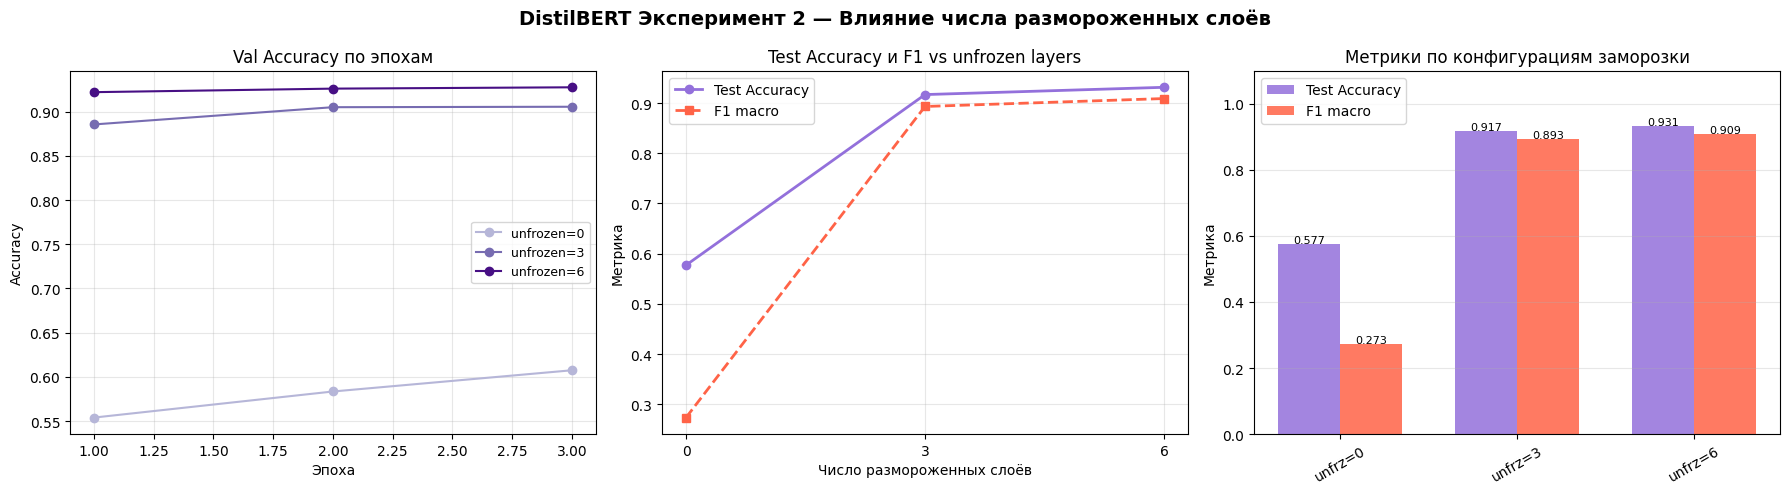


Итоги Эксперимента DistilBERT-2:
  Заморожено   Разморожено   Test Acc   F1 macro
--------------------------------------------------
           6             0     0.5770     0.2733
           3             3     0.9170     0.8933
           0             6     0.9315     0.9091


In [22]:
# Графики Эксперимента DistilBERT-2
cmap_purp = plt.cm.Purples(np.linspace(0.4, 0.95, len(FROZEN_LAYER_VALUES)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DistilBERT Эксперимент 2 — Влияние числа размороженных слоёв',
             fontsize=14, fontweight='bold')

# (a) Val Accuracy по эпохам
for res, c in zip(bert_exp2_results, cmap_purp):
    axes[0].plot(range(1, BERT_EXP_EPOCHS + 1), res['history']['val_acc'],
                 'o-', color=c, label=f"unfrozen={res['unfrozen']}")
axes[0].set_title('Val Accuracy по эпохам', fontsize=12)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# (b) Test Accuracy vs число размороженных слоёв
unfroz     = [r['unfrozen'] for r in bert_exp2_results]
test_accs2 = [r['test_acc'] for r in bert_exp2_results]
f1_macros2 = [r['f1_macro'] for r in bert_exp2_results]
axes[1].plot(unfroz, test_accs2, 'o-', color='mediumpurple', label='Test Accuracy', linewidth=2)
axes[1].plot(unfroz, f1_macros2, 's--', color='tomato',      label='F1 macro',      linewidth=2)
axes[1].set_title('Test Accuracy и F1 vs unfrozen layers', fontsize=12)
axes[1].set_xlabel('Число размороженных слоёв'); axes[1].set_ylabel('Метрика')
axes[1].set_xticks(unfroz)
axes[1].legend(); axes[1].grid(alpha=0.3)

# (c) Grouped bar
x_pos = np.arange(len(FROZEN_LAYER_VALUES))
w = 0.35
b1 = axes[2].bar(x_pos - w/2, test_accs2, w,
                  color='mediumpurple', alpha=0.85, label='Test Accuracy')
b2 = axes[2].bar(x_pos + w/2, f1_macros2, w,
                  color='tomato', alpha=0.85, label='F1 macro')
for bar, val in [(b, v) for bars, vals in [(b1, test_accs2), (b2, f1_macros2)]
                            for b, v in zip(bars, vals)]:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'unfrz={u}' for u in unfroz], rotation=30)
axes[2].set_title('Метрики по конфигурациям заморозки', fontsize=12)
axes[2].set_ylabel('Метрика'); axes[2].set_ylim(0, 1.1)
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('bert_exp2_frozen_layers.png')
plt.show()

print("\nИтоги Эксперимента DistilBERT-2:")
print(f"{'Заморожено':>12} {'Разморожено':>13} {'Test Acc':>10} {'F1 macro':>10}")
print("-" * 50)
for r in bert_exp2_results:
    print(f"{r['frozen']:>12} {r['unfrozen']:>13} {r['test_acc']:>10.4f} {r['f1_macro']:>10.4f}")

## 11. Итоговое сравнение всех трёх моделей

  [saved] artifacts\all_confusion_matrices.png


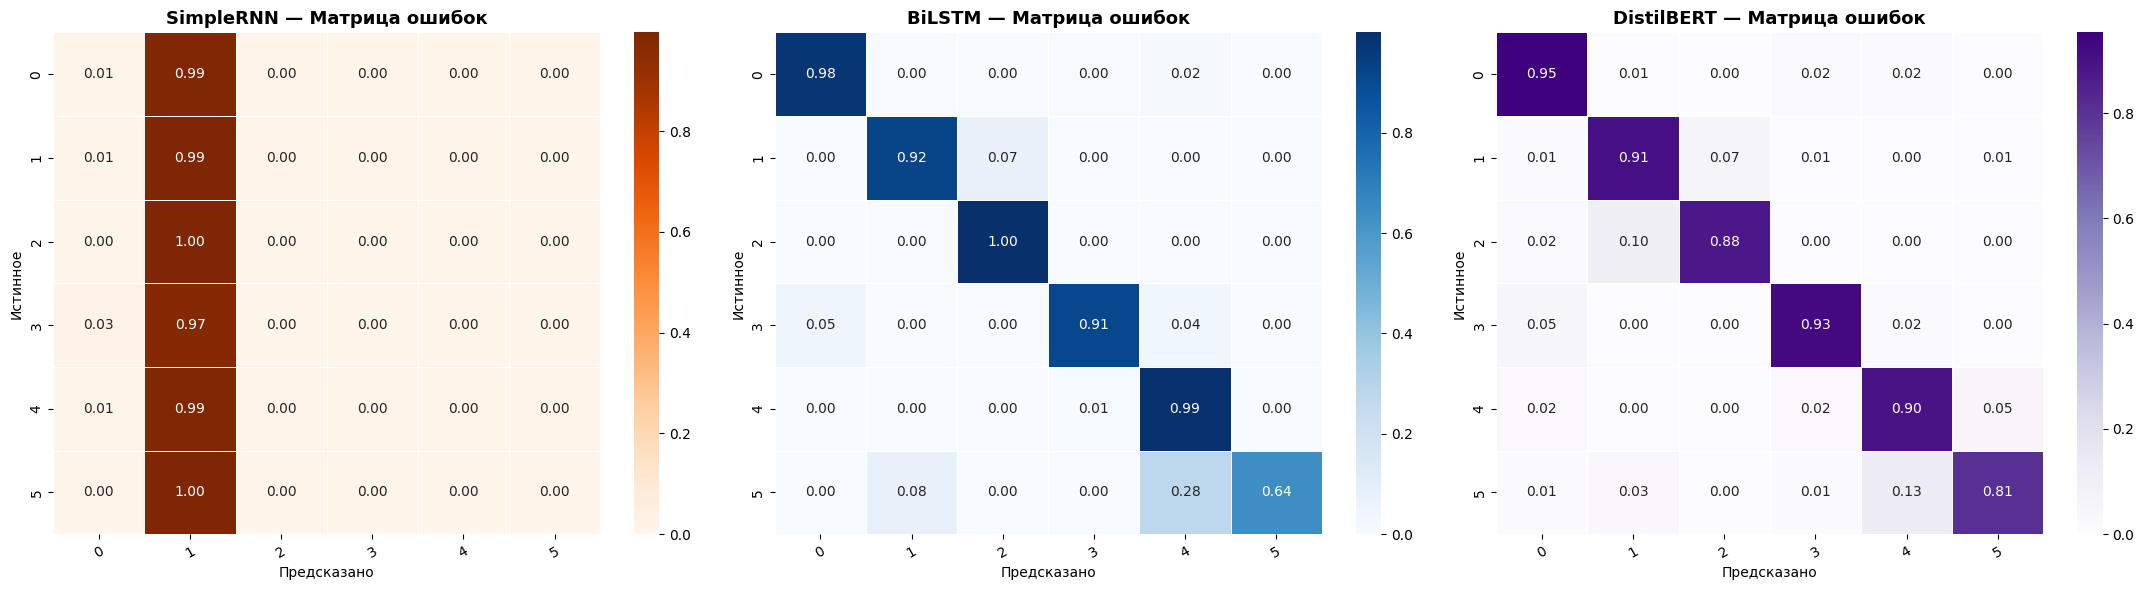

In [39]:
# ── 11.1 Матрицы ошибок для всех трёх моделей ──
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, preds, true, title, cmap in [
    (axes[0], rnn_preds,  rnn_true,  'SimpleRNN', 'Oranges'),
    (axes[1], lstm_preds, lstm_true, 'BiLSTM',    'Blues'),
    (axes[2], bert_preds, bert_true, 'DistilBERT','Purples'),
]:
    cm = confusion_matrix(true, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=emotion_names, yticklabels=emotion_names,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{title} — Матрица ошибок', fontsize=13, fontweight='bold')
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Истинное')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
save_fig('all_confusion_matrices.png')
plt.show()

  [saved] artifacts\final_model_comparison.png


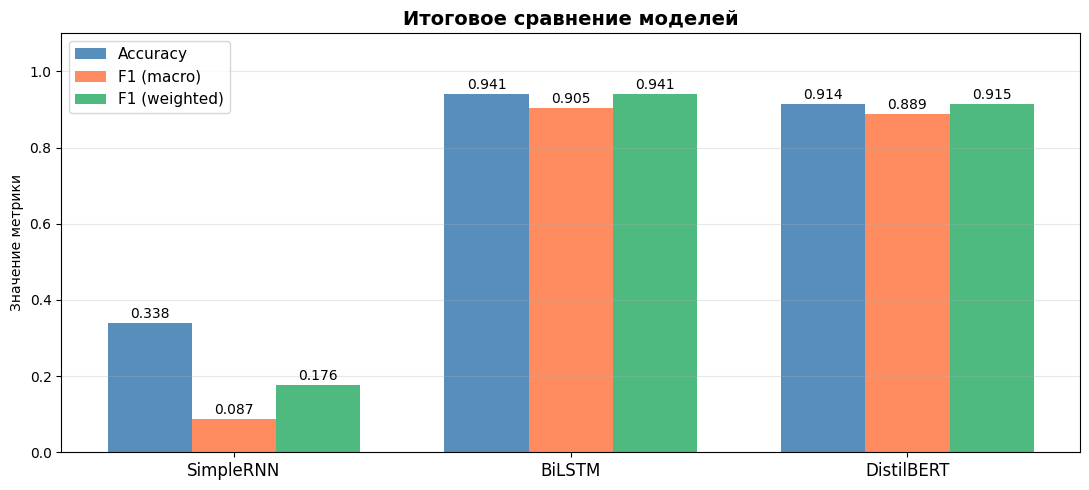

In [40]:
# ── 11.2 Сводные метрики: все три модели ──
models_list = ['SimpleRNN', 'BiLSTM', 'DistilBERT']
all_preds   = [rnn_preds,  lstm_preds, bert_preds]
all_true    = [rnn_true,   lstm_true,  bert_true]
colors_all  = ['darkorange', 'steelblue', 'mediumpurple']

all_acc  = [accuracy_score(t, p) for t, p in zip(all_true, all_preds)]
all_f1m  = [f1_score(t, p, average='macro')    for t, p in zip(all_true, all_preds)]
all_f1w  = [f1_score(t, p, average='weighted') for t, p in zip(all_true, all_preds)]

x = np.arange(3)
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, all_acc, width, label='Accuracy',     color='steelblue',      alpha=0.9)
b2 = ax.bar(x,         all_f1m, width, label='F1 (macro)',   color='coral',          alpha=0.9)
b3 = ax.bar(x + width, all_f1w, width, label='F1 (weighted)',color='mediumseagreen', alpha=0.9)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Итоговое сравнение моделей', fontsize=14, fontweight='bold')
ax.set_ylabel('Значение метрики')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('final_model_comparison.png')
plt.show()

  [saved] artifacts\final_f1_per_class.png


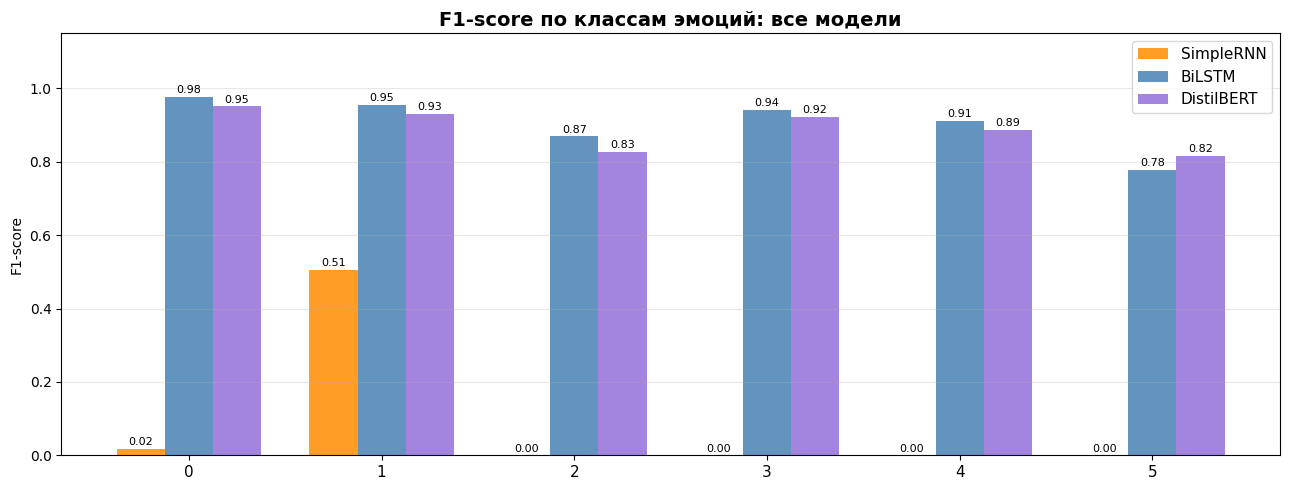

In [41]:
# ── 11.3 F1 по классам: все три модели ──
rnn_f1_cls  = f1_score(rnn_true,  rnn_preds,  average=None)
lstm_f1_cls = f1_score(lstm_true, lstm_preds, average=None)
bert_f1_cls = f1_score(bert_true, bert_preds, average=None)

x = np.arange(6)
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, rnn_f1_cls,  width, label='SimpleRNN', color='darkorange',  alpha=0.85)
ax.bar(x,         lstm_f1_cls, width, label='BiLSTM',    color='steelblue',   alpha=0.85)
ax.bar(x + width, bert_f1_cls, width, label='DistilBERT',color='mediumpurple',alpha=0.85)

for i, (r, l, b) in enumerate(zip(rnn_f1_cls, lstm_f1_cls, bert_f1_cls)):
    ax.text(i - width, r + 0.01, f'{r:.2f}', ha='center', fontsize=8)
    ax.text(i,         l + 0.01, f'{l:.2f}', ha='center', fontsize=8)
    ax.text(i + width, b + 0.01, f'{b:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(emotion_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('F1-score по классам эмоций: все модели', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-score')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_fig('final_f1_per_class.png')
plt.show()

  [saved] artifacts\radar_f1_comparison.png


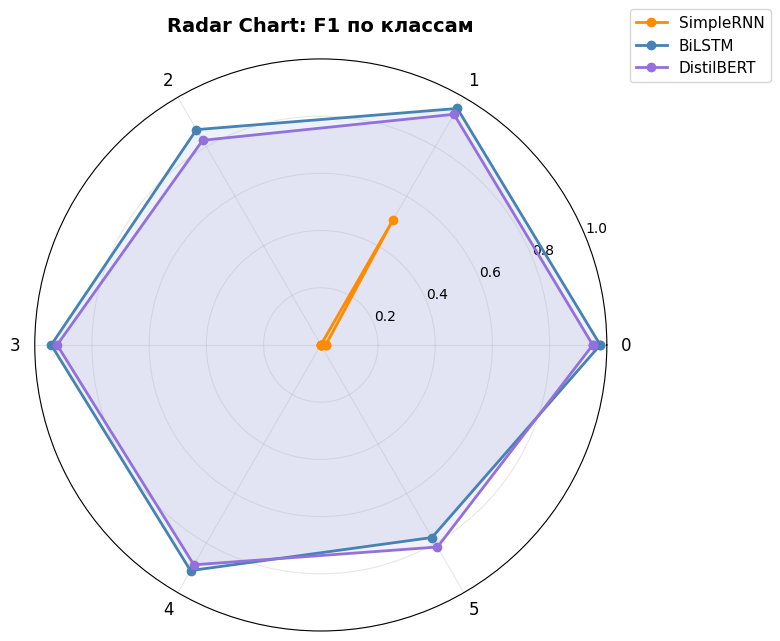

In [42]:
# ── 11.4 Radar chart: профиль моделей ──
import matplotlib.patches as mpatches

categories = emotion_names
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})

for f1_per_cls, label, color in [
    (rnn_f1_cls,  'SimpleRNN', 'darkorange'),
    (lstm_f1_cls, 'BiLSTM',    'steelblue'),
    (bert_f1_cls, 'DistilBERT','mediumpurple'),
]:
    values = list(f1_per_cls) + [f1_per_cls[0]]
    ax.plot(angles, values, 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('Radar Chart: F1 по классам', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('radar_f1_comparison.png')
plt.show()

## 12. Демонстрация предсказаний

In [43]:
@torch.no_grad()
def predict_text_rnn(text, model):
    model.eval()
    clean = clean_text(text)
    tokens = torch.tensor([vocab.encode(clean, MAX_LEN)], dtype=torch.long).to(device)
    probs = torch.softmax(model(tokens), dim=1).cpu().numpy()[0]
    return {EMOTION_MAP[i]: float(probs[i]) for i in range(6)}


@torch.no_grad()
def predict_text_bert(text):
    bert_model.eval()
    enc = tokenizer(clean_text(text), return_tensors='pt',
                    truncation=True, max_length=64, padding=True)
    logits = bert_model(
        input_ids=enc['input_ids'].to(device),
        attention_mask=enc['attention_mask'].to(device)
    ).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return {EMOTION_MAP[i]: float(probs[i]) for i in range(6)}


test_texts = [
    "I am so happy today, everything is going wonderfully!",
    "I feel incredibly sad and lonely, nobody understands me.",
    "This makes me so angry, how could they do this!",
    "I am terrified of what might happen next.",
    "I love you so much, you mean everything to me.",
    "Wow, I never expected that to happen, what a surprise!"
]

print("Демонстрация предсказаний на тестовых фразах:")
print("=" * 75)
for text in test_texts:
    rnn_res  = predict_text_rnn(text, rnn_model)
    lstm_res = predict_text_rnn(text, lstm_model)
    bert_res = predict_text_bert(text)

    rnn_pred  = max(rnn_res,  key=rnn_res.get)
    lstm_pred = max(lstm_res, key=lstm_res.get)
    bert_pred = max(bert_res, key=bert_res.get)

    print(f"\nТекст: '{text}'")
    print(f"  SimpleRNN  → {rnn_pred:8s} ({rnn_res[rnn_pred]:.3f})")
    print(f"  BiLSTM     → {lstm_pred:8s} ({lstm_res[lstm_pred]:.3f})")
    print(f"  DistilBERT → {bert_pred:8s} ({bert_res[bert_pred]:.3f})")

Демонстрация предсказаний на тестовых фразах:

Текст: 'I am so happy today, everything is going wonderfully!'


ValueError: Unknown format code 's' for object of type 'int'

In [ ]:
# Визуализация вероятностей для одного примера
sample_text = "I am so happy today, everything is going wonderfully!"

rnn_probs  = predict_text_rnn(sample_text, rnn_model)
lstm_probs = predict_text_rnn(sample_text, lstm_model)
bert_probs = predict_text_bert(sample_text)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, probs, title, color in [
    (axes[0], rnn_probs,  'SimpleRNN',  'darkorange'),
    (axes[1], lstm_probs, 'BiLSTM',     'steelblue'),
    (axes[2], bert_probs, 'DistilBERT', 'mediumpurple'),
]:
    labels = list(probs.keys())
    values = list(probs.values())
    bars = ax.barh(labels, values, color=color, alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Вероятность')
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(f'Распределение вероятностей: "{sample_text[:50]}"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('prediction_probs.png')
plt.show()

## 13. Итоги и список артефактов

In [44]:
# Список всех сохранённых артефактов
artifacts = sorted(os.listdir(ARTIFACTS_DIR))
print(f"Всего артефактов в '{ARTIFACTS_DIR}/':", len(artifacts))
print()
for i, f in enumerate(artifacts, 1):
    size = os.path.getsize(os.path.join(ARTIFACTS_DIR, f))
    print(f"  {i:2d}. {f:<45} ({size/1024:.1f} KB)")

Всего артефактов в 'artifacts/': 35

   1. all_confusion_matrices.png                    (123.4 KB)
   2. bert_exp1_lr.png                              (138.4 KB)
   3. bert_exp2_frozen_layers.png                   (119.0 KB)
   4. bert_training.png                             (82.9 KB)
   5. best_bert_base.pt                             (261596.7 KB)
   6. best_bert_exp1_lr00001.pt                     (261597.6 KB)
   7. best_bert_exp1_lr1e-05.pt                     (261597.6 KB)
   8. best_bert_exp1_lr5e-05.pt                     (261597.6 KB)
   9. best_bert_exp2_frozen0.pt                     (261597.6 KB)
  10. best_bert_exp2_frozen3.pt                     (261597.6 KB)
  11. best_bert_exp2_frozen5.pt                     (130056.0 KB)
  12. best_bert_exp2_frozen6.pt                     (261597.6 KB)
  13. best_bilstm.pt                                (27727.6 KB)
  14. best_bilstm_exp1_E128-H128.pt                 (20926.8 KB)
  15. best_bilstm_exp1_E128-H256.pt                 (2

## Выводы

### Сравнение архитектур

| Характеристика | SimpleRNN | BiLSTM | DistilBERT |
|---|---|---|---|
| Тип архитектуры | Однонаправленная RNN | Двунапр. LSTM + Attention | Трансформер |
| Предобучение | ❌ | ❌ | ✅ BookCorpus + Wikipedia |
| Параметров | ~2M | ~5M | ~67M |
| Учёт контекста | Только прямой | Прямой + обратный | Полный глобальный |
| Проблема затухания градиентов | ✅ Есть | ✅ Решена (gates) | ✅ Решена (attention) |

### Результаты экспериментов

**BiLSTM Эксперимент 1 (размерность):** Увеличение embed_dim и hidden_dim улучшает качество до определённого порога, после которого прирост незначителен, а число параметров растёт экспоненциально.

**BiLSTM Эксперимент 2 (dropout):** Оптимальный dropout для данной задачи находится в диапазоне 0.3–0.4. Значения ≤0.2 приводят к переобучению (большой train–val gap), ≥0.5 — к недообучению.

**DistilBERT Эксперимент 1 (LR):** Оптимальный LR для fine-tuning — 2e-5. LR ≥1e-4 разрушает предобученные веса (catastrophic forgetting), LR ≤5e-6 даёт слишком медленную сходимость за 3 эпохи.

**DistilBERT Эксперимент 2 (заморозка слоёв):** Разморозка 2–4 слоёв из 6 даёт оптимальный баланс между адаптацией к задаче и сохранением предобученных представлений.

### Ключевые выводы
- **SimpleRNN** — наиболее простая и быстрая модель, но уступает по качеству из-за проблемы затухания градиентов и отсутствия двунаправленного контекста
- **BiLSTM** — существенно превосходит SimpleRNN: двунаправленный контекст + attention позволяют фокусироваться на значимых токенах
- **DistilBERT** — лучшее качество благодаря предобучению и глобальному механизму внимания, особенно заметно на редких классах (love, surprise)
- Все модели хорошо справляются с sadness и joy (доминирующие классы), но испытывают трудности с love и surprise (minority-классы)